In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.base import clone

from xgboost import XGBRegressor

# Data Loading

In [2]:
folder_path = './data/'

train = pd.read_csv(f'{folder_path}train.csv', index_col=0)
test = pd.read_csv(f'{folder_path}test.csv', index_col=0)

exam_score_data = pd.read_csv(f'{folder_path}Exam_Score_Prediction.csv', index_col=0)

full_train = pd.concat([train, exam_score_data], axis=0)

X = full_train.iloc[:, :-1]
y = full_train['exam_score']

X.sample(5)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
78860,17,other,bba,2.57,99.4,yes,6.9,good,online videos,medium,moderate
238411,21,other,b.sc,0.78,55.4,yes,4.1,poor,online videos,medium,moderate
558844,21,female,b.sc,3.31,67.8,yes,4.2,good,group study,low,moderate
539561,18,other,bca,0.72,60.4,no,7.0,poor,mixed,low,moderate
571524,24,female,b.sc,0.14,89.0,yes,4.1,good,group study,medium,moderate


# Exploratory Data Analysis

### Statistics

In [3]:
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nSummary Statistics:")
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 650000 entries, 0 to 20001
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               650000 non-null  int64  
 1   gender            650000 non-null  object 
 2   course            650000 non-null  object 
 3   study_hours       650000 non-null  float64
 4   class_attendance  650000 non-null  float64
 5   internet_access   650000 non-null  object 
 6   sleep_hours       650000 non-null  float64
 7   sleep_quality     650000 non-null  object 
 8   study_method      650000 non-null  object 
 9   facility_rating   650000 non-null  object 
 10  exam_difficulty   650000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 59.5+ MB
None

Missing Values:
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_meth

### Target distribution

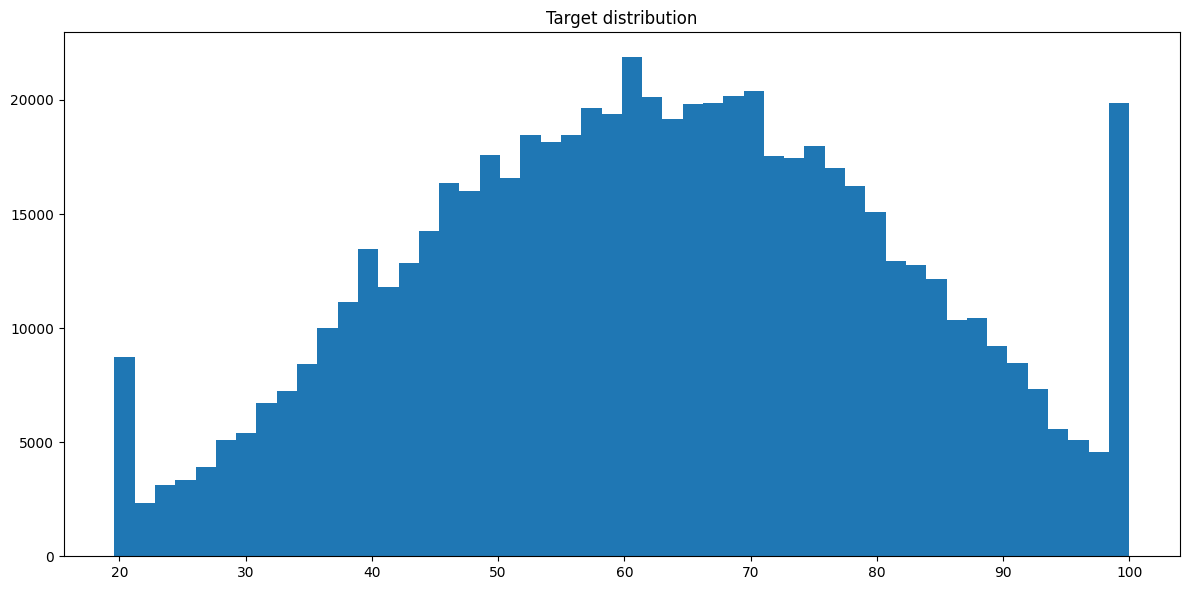

In [4]:
plt.figure(figsize=(12, 6))
plt.hist(full_train['exam_score'], bins=50)
plt.title('Target distribution')
plt.tight_layout()
plt.show()

### Mutual information

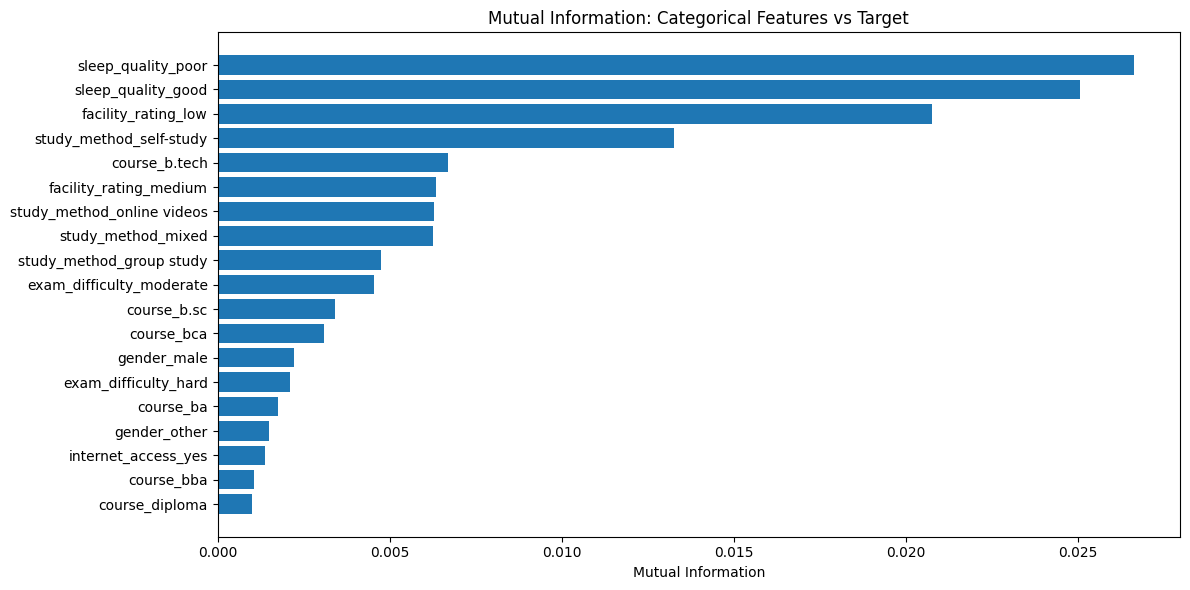

In [5]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

X_cat_enc = pd.get_dummies(X[cat_cols], drop_first=True)

mi = mutual_info_regression(X_cat_enc, y)
mi = pd.Series(mi, index=X_cat_enc.columns)
mi = mi.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(mi.index, mi.values)
plt.xlabel("Mutual Information")
plt.title("Mutual Information: Categorical Features vs Target")
plt.tight_layout()
plt.show()

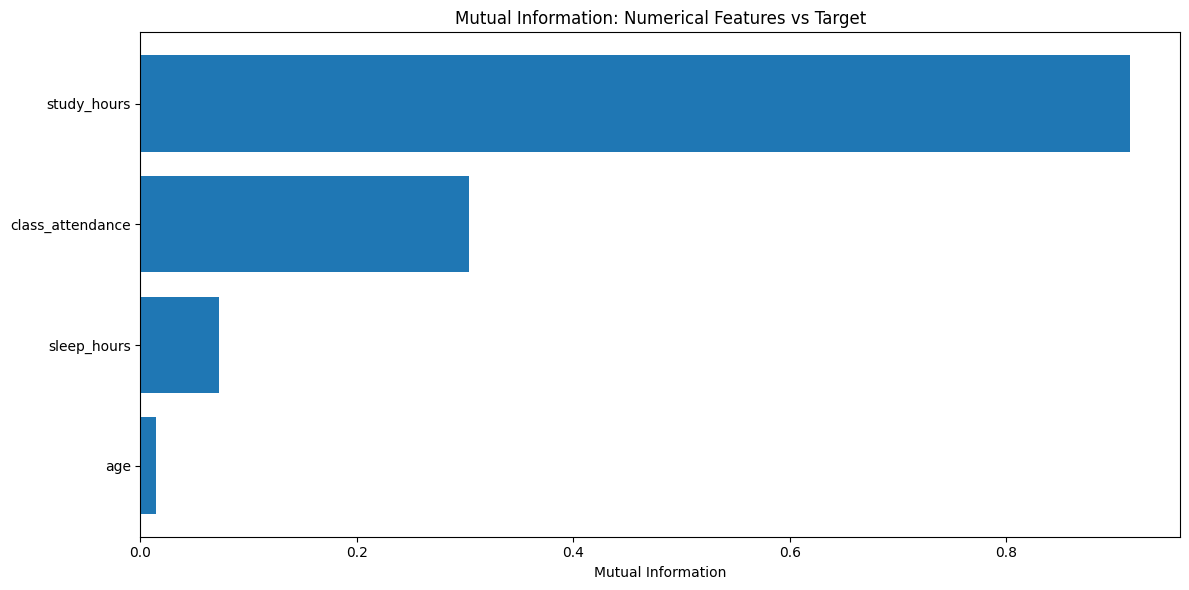

In [6]:
mi = mutual_info_regression(X[num_cols], y)
mi = pd.Series(mi, index=num_cols)
mi = mi.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(mi.index, mi.values)
plt.xlabel("Mutual Information")
plt.title("Mutual Information: Numerical Features vs Target")
plt.tight_layout()
plt.show()

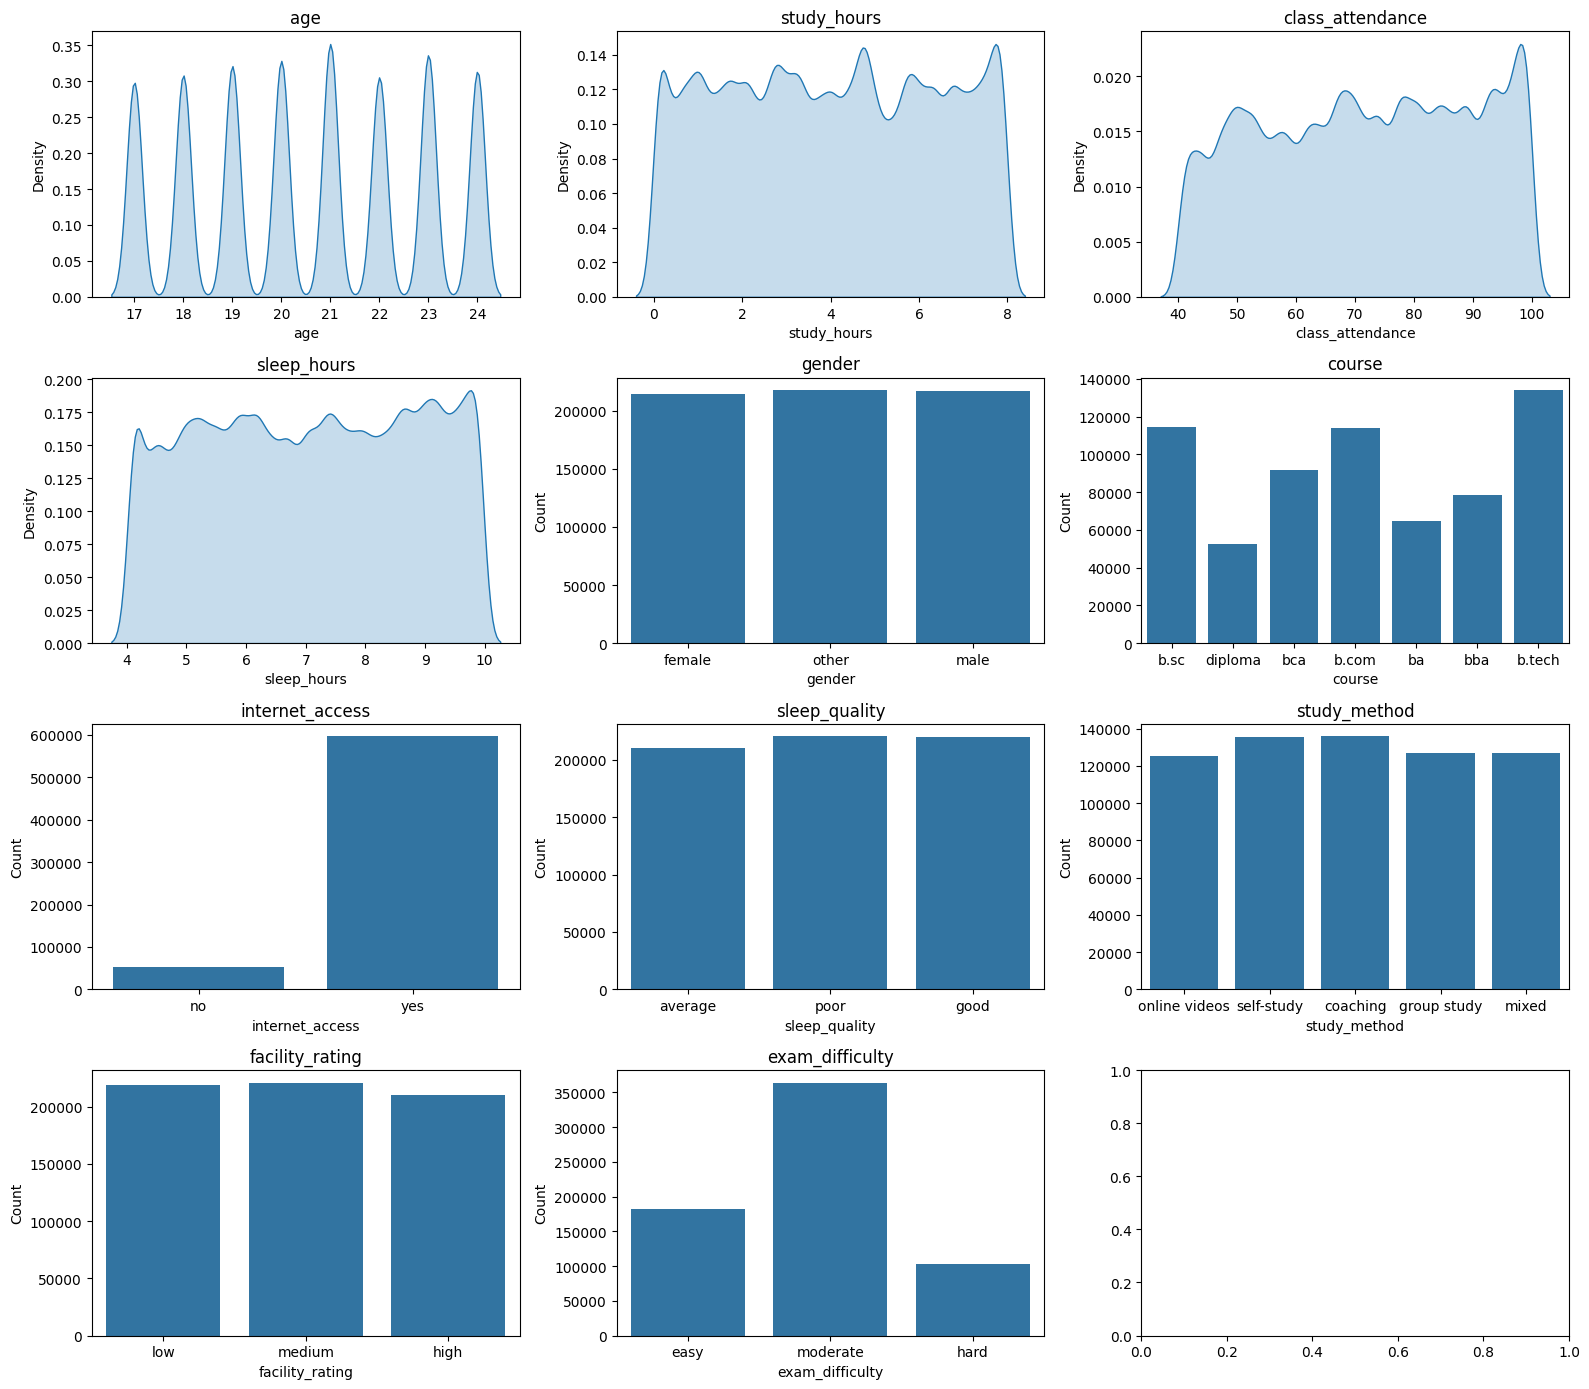

In [7]:
cols_quant = len(cat_cols) + len(num_cols)
rows = 4
fig, axes = plt.subplots(rows, cols_quant//rows+1, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(X[col], fill=True, ax=axes[i])
    axes[i].set_ylabel("Density")
    axes[i].set_title(col)

for i, col in enumerate(cat_cols):
    i += len(num_cols)
    sns.countplot(x=X[col], ax=axes[i])
    axes[i].set_ylabel("Count")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Feature Engineering

In [8]:
def feature_engineering(X):
    X = X.copy()
    eps = 1e-5
    
    facility_map = {'low': 0, 'medium': 1, 'high': 2}
    X['facility_rating'] = X['facility_rating'].map(facility_map)
    X['internet_access'] = (X['internet_access'] == 'yes').astype(int)
    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    X['sleep_quality'] = X['sleep_quality'].map(sleep_quality_map)
    exam_difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}
    X['exam_difficulty'] = X['exam_difficulty'].map(exam_difficulty_map)

    X['study_hours_times_attendance'] = X['study_hours'] * X['class_attendance']
    X['study_hours_times_sleep'] = X['study_hours'] * X['sleep_hours']
    X['age_times_study_hours'] = X['age'] * X['study_hours']

    X['study_hours_over_sleep'] = X['study_hours'] / (X['sleep_hours'] + eps)
    X['attendance_over_sleep'] = X['class_attendance'] / (X['sleep_hours'] + eps)

    X['study_hours_times_sleep_quality'] = X['study_hours'] * X['sleep_quality']
    X['attendance_times_facility'] = X['class_attendance'] * X['facility_rating']

    X['high_att_high_study'] = ((X['class_attendance'] >= 90) & (X['study_hours'] >= 6)).astype(int)
    X['ideal_sleep_flag'] = ((X['sleep_hours'] >= 7) & (X['sleep_hours'] <= 9)).astype(int)

    X['efficiency'] = (X['study_hours'] * X['class_attendance']) / (X['sleep_hours'] + 1)
    X['sleep_gap_8'] = (X['sleep_hours'] - 8.0).abs()
    
    return X

### Split the data

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

# XGB

In [10]:
xgb_params = {
    'learning_rate': 0.0177,
    'n_estimators': 100000,
    'max_depth': 7,
    'subsample': 0.783,
    'colsample_bytree': 0.518,
    'min_child_weight': 3,
    'gamma': 3.771,
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'reg_lambda': 5,
    'early_stopping_rounds': 100
}

cat_cols = ['gender', 'course', 'study_method']
num_cols = X.drop(columns=cat_cols).columns.tolist()

std_scaler = StandardScaler()
f_prep = FunctionTransformer(feature_engineering)
oh_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

preprocessor = Pipeline([
    ('feat', f_prep),
    ('cols', ColumnTransformer([
        ('num', std_scaler,
         make_column_selector(dtype_include=np.number)),

        ('cat', oh_enc, cat_cols),
    ]))
])

kf = KFold(n_splits=4, shuffle=True, random_state=0)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    fold_preprocessor = clone(preprocessor)
    xgb = XGBRegressor(**xgb_params)

    X_tr_prep = fold_preprocessor.fit_transform(X_train)
    X_val_prep = fold_preprocessor.transform(X_val)
    X_test_prep = fold_preprocessor.transform(test)

    xgb.fit(
        X_tr_prep, y_train,
        eval_set=[(X_val_prep, y_val)],
        verbose=250
    )

    oof_preds[val_idx] = xgb.predict(X_val_prep)

    test_preds += xgb.predict(X_test_prep) / kf.n_splits

rmse = root_mean_squared_error(y, oof_preds)
print("OOF RMSE:", rmse)


[0]	validation_0-rmse:18.71231
[250]	validation_0-rmse:8.86985
[500]	validation_0-rmse:8.82773
[750]	validation_0-rmse:8.81023
[1000]	validation_0-rmse:8.79810
[1250]	validation_0-rmse:8.79047
[1500]	validation_0-rmse:8.78434
[1750]	validation_0-rmse:8.78103
[2000]	validation_0-rmse:8.77812
[2250]	validation_0-rmse:8.77571
[2500]	validation_0-rmse:8.77449
[2750]	validation_0-rmse:8.77389
[3000]	validation_0-rmse:8.77285
[3250]	validation_0-rmse:8.77236
[3500]	validation_0-rmse:8.77206
[3622]	validation_0-rmse:8.77205
[0]	validation_0-rmse:18.65721
[250]	validation_0-rmse:8.86887
[500]	validation_0-rmse:8.82575
[750]	validation_0-rmse:8.80823
[1000]	validation_0-rmse:8.79767
[1250]	validation_0-rmse:8.79080
[1500]	validation_0-rmse:8.78513
[1750]	validation_0-rmse:8.78161
[2000]	validation_0-rmse:8.77881
[2250]	validation_0-rmse:8.77706
[2500]	validation_0-rmse:8.77592
[2750]	validation_0-rmse:8.77499
[3000]	validation_0-rmse:8.77451
[3250]	validation_0-rmse:8.77357
[3500]	validation_0-

In [11]:
sample_submission = pd.read_csv(f'{folder_path}sample_submission.csv')
submission = pd.DataFrame({
    'id': test.index,
    'exam_score': test_preds
}).to_csv('submission.csv', index=False)